In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uttamkantidutta/amazon-review/meta_Electronics.jsonl


In [1]:
import pandas as pd
import numpy as np
import json
import random

# Review dataset
review_path = "/kaggle/input/datasets/uttamkantidutta/review-dataset-amazon/Electronics.jsonl"

# Product metadata
meta_path = "/kaggle/input/datasets/uttamkantidutta/amazon-review/meta_Electronics.jsonl"

In [2]:
review_cols = [
    "rating",
    "title",
    "text",
    "parent_asin",
    "timestamp",
    "helpful_vote",
    "verified_purchase"
]

meta_cols = [
    "parent_asin",
    "title",
    "main_category",
    "store",
    "price"
]

In [3]:
SAMPLE_SIZE = 200_000
random.seed(42)

reservoir = []

with open(review_path, "r", encoding="utf-8") as f:
    
    for i, line in enumerate(f):
        
        row = json.loads(line)
        
        # Skip reviews without usable text
        text = row.get("text")
        
        if text is None or str(text).strip() == "":
            continue
        
        # Keep only useful columns
        record = {
            col: row.get(col)
            for col in review_cols
        }
        
        # Fill reservoir initially
        if len(reservoir) < SAMPLE_SIZE:
            reservoir.append(record)
            
        else:
            # Reservoir sampling
            j = random.randint(0, i)
            
            if j < SAMPLE_SIZE:
                reservoir[j] = record

reviews = pd.DataFrame(reservoir)

In [4]:
reviews

,rating,title,text,parent_asin,timestamp,helpful_vote,verified_purchase
0,4.0,Oodles of books in one,This is my 3td kindle and I love being able to...,B07T6XMZQZ,1637339728676,0,True
1,2.0,Basically ok but issues exist,Build quality is fine and the Windows 11 came ...,B0C7KBYGN4,1674484182661,0,True
2,1.0,Does not work.,Would not connect to my computer even with tec...,B09G9STJF6,1677333384912,0,True
3,5.0,The best filter holder for the 15-30mm Tamron ...,"Like most lenses with bulbous front element, u...",B01738GIQG,1653231610658,0,True
4,5.0,Great battery,Work perfectly.,B000NK5Z8Y,1453388435000,0,True
...,...,...,...,...,...,...,...
199995,2.0,"The sound was good, but I had to return them","The sound was good, but I had to return them. ...",B00WSM6W8W,1406003667000,0,True
199996,4.0,Order an AX210 WiFi card for it now!,The laptop is great. Plays just about everyth...,B09J2BCP87,1650915585571,1,True
199997,5.0,Amazing,This amplifier is exactly what I was looking f...,B07Q41YB14,1612015877739,0,True
199998,5.0,Perfect Tablet,My high school son is impressed with everythin...,B00FFVYSMK,1389695793000,1,True


<Axes: xlabel='rating'>

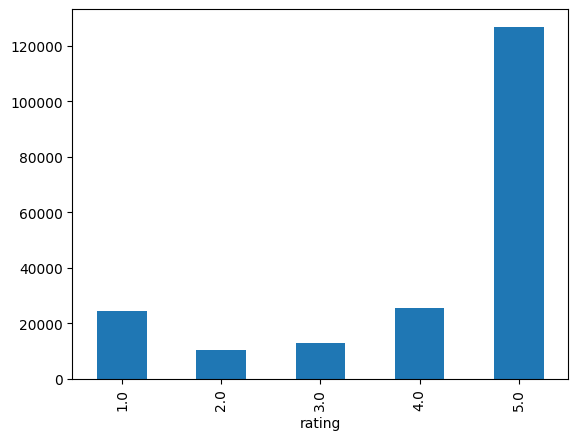

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
reviews['rating'].value_counts().sort_index().plot(kind = 'bar')

In [9]:
import json

meta_path = "/kaggle/input/datasets/uttamkantidutta/amazon-review/meta_Electronics.jsonl"
meta_cols = ["parent_asin", "title", "main_category", "store", "price"]

# Get the set of unique product IDs from your sampled reviews
needed_products = set(reviews["parent_asin"].dropna().unique())

metadata_records = []
with open(meta_path, "r", encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        if row.get("parent_asin") in needed_products:
            metadata_records.append({col: row.get(col) for col in meta_cols})

metadata = pd.DataFrame(metadata_records)

In [10]:
metadata

,parent_asin,title,main_category,store,price
0,B07Y6MRH7G,KEiiD PC Computer Speaker Compact Bluetooth St...,All Electronics,KEiiD,None
1,B07M9421GV,Street Guardian SGGCX2PRO+ Dash Camera with GP...,Cell Phones & Accessories,Street Guardian,None
2,B09M7TH3YC,Wenlaty Case Compatible with iPad 9th /8th /7t...,Cell Phones & Accessories,Wenlaty,19.99
3,B0BSQL7M51,PNY 1TB PRO Elite Class 10 U3 V30 microSDXC Fl...,Computers,PNY,109.99
4,B07MVKYVVL,10-Pack Replacement Clamp Bluetooth Ear Hook L...,Home Audio & Theater,Tricon,3.49
...,...,...,...,...,...
97558,B0B467QYSB,SUNMALL Replacement Keyboard Compatible with H...,Computers,SUNMALL,25.99
97559,B00YOLUBAK,Fujimoto Dengyo Apple Watch Band…,None,Oittm,None
97560,B000EI3W62,Optoma EP910 SXGA Plus Projector,All Electronics,Optoma,None
97561,B009ARLGXO,HPx4500 Wireless Comfort Mouse,Computers,HEWLETT PACKARD,None


In [11]:
reviews = reviews.rename(
    columns={"title": "review_title"}
)

metadata = metadata.rename(
    columns={"title": "product_title"}
)

In [12]:
metadata = metadata.drop_duplicates(
    subset="parent_asin"
)

print(metadata["parent_asin"].duplicated().sum())

0


In [13]:
final_df = reviews.merge(
    metadata,
    on = "parent_asin",
    how = "left",
    validate="many_to_one"
)

print(final_df.shape)

(200000, 11)


In [14]:
final_df.head()

,rating,review_title,text,parent_asin,timestamp,helpful_vote,verified_purchase,product_title,main_category,store,price
0,4.0,Oodles of books in one,This is my 3td kindle and I love being able to...,B07T6XMZQZ,1637339728676,0,True,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",Computers,Fintie,21.99
1,2.0,Basically ok but issues exist,Build quality is fine and the Windows 11 came ...,B0C7KBYGN4,1674484182661,0,True,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Computers,Beelink,649.0
2,1.0,Does not work.,Would not connect to my computer even with tec...,B09G9STJF6,1677333384912,0,True,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Computers,ROOFULL,21.99
3,5.0,The best filter holder for the 15-30mm Tamron ...,"Like most lenses with bulbous front element, u...",B01738GIQG,1653231610658,0,True,NiSi 150mm Aluminum Square Filter Holder Speci...,Camera & Photo,NiSi,None
4,5.0,Great battery,Work perfectly.,B000NK5Z8Y,1453388435000,0,True,STK NB-5L Battery For Canon Powershot SD790 El...,Camera & Photo,SterlingTek,13.99


In [15]:
final_df

,rating,review_title,text,parent_asin,timestamp,helpful_vote,verified_purchase,product_title,main_category,store,price
0,4.0,Oodles of books in one,This is my 3td kindle and I love being able to...,B07T6XMZQZ,1637339728676,0,True,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",Computers,Fintie,21.99
1,2.0,Basically ok but issues exist,Build quality is fine and the Windows 11 came ...,B0C7KBYGN4,1674484182661,0,True,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Computers,Beelink,649.0
2,1.0,Does not work.,Would not connect to my computer even with tec...,B09G9STJF6,1677333384912,0,True,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Computers,ROOFULL,21.99
3,5.0,The best filter holder for the 15-30mm Tamron ...,"Like most lenses with bulbous front element, u...",B01738GIQG,1653231610658,0,True,NiSi 150mm Aluminum Square Filter Holder Speci...,Camera & Photo,NiSi,None
4,5.0,Great battery,Work perfectly.,B000NK5Z8Y,1453388435000,0,True,STK NB-5L Battery For Canon Powershot SD790 El...,Camera & Photo,SterlingTek,13.99
...,...,...,...,...,...,...,...,...,...,...,...
199995,2.0,"The sound was good, but I had to return them","The sound was good, but I had to return them. ...",B00WSM6W8W,1406003667000,0,True,"Koss KSC75 Portable Stereophone Headphones, Si...",Home Audio & Theater,Koss,25.32
199996,4.0,Order an AX210 WiFi card for it now!,The laptop is great. Plays just about everyth...,B09J2BCP87,1650915585571,1,True,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",Computers,ASUS,2499.99
199997,5.0,Amazing,This amplifier is exactly what I was looking f...,B07Q41YB14,1612015877739,0,True,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,All Electronics,Pyle,28.66
199998,5.0,Perfect Tablet,My high school son is impressed with everythin...,B00FFVYSMK,1389695793000,1,True,Dell Venue 8 32 GB Tablet (Android),Computers,Dell,None


In [16]:
final_df.isnull().sum()

rating                   0
review_title             0
text                     0
parent_asin              0
timestamp                0
helpful_vote             0
verified_purchase        0
product_title            0
main_category         3362
store                  266
price                83156
dtype: int64

In [17]:
match_rate = final_df["product_title"].notna().mean() * 100

print(f"Metadata match rate: {match_rate:.2f}%")

Metadata match rate: 100.00%


In [19]:
final_df = final_df[[
    "parent_asin",
    "product_title",
    "main_category",
    "rating",
    "text",
    "timestamp",
    "helpful_vote",
    "verified_purchase",
    "price"
]].copy()

final_df.head()

,parent_asin,product_title,main_category,rating,text,timestamp,helpful_vote,verified_purchase,price
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",Computers,4.0,This is my 3td kindle and I love being able to...,1637339728676,0,True,21.99
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Computers,2.0,Build quality is fine and the Windows 11 came ...,1674484182661,0,True,649.0
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Computers,1.0,Would not connect to my computer even with tec...,1677333384912,0,True,21.99
3,B01738GIQG,NiSi 150mm Aluminum Square Filter Holder Speci...,Camera & Photo,5.0,"Like most lenses with bulbous front element, u...",1653231610658,0,True,None
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Camera & Photo,5.0,Work perfectly.,1453388435000,0,True,13.99


In [21]:
final_df['price'] = pd.to_numeric(
    final_df["price"],
    errors = "coerce"
)

In [22]:
final_df["price_missing"] = final_df["price"].isna().astype(int)

In [23]:
price_df = final_df.dropna(subset = ["price"]).copy()

In [24]:
price_df

,parent_asin,product_title,main_category,rating,text,timestamp,helpful_vote,verified_purchase,price,price_missing
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",Computers,4.0,This is my 3td kindle and I love being able to...,1637339728676,0,True,21.99,0
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Computers,2.0,Build quality is fine and the Windows 11 came ...,1674484182661,0,True,649.00,0
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Computers,1.0,Would not connect to my computer even with tec...,1677333384912,0,True,21.99,0
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Camera & Photo,5.0,Work perfectly.,1453388435000,0,True,13.99,0
8,B014LBW3TY,Cube Tracker Key Finder Locator Smart Bluetoot...,Cell Phones & Accessories,5.0,Works great. Fantastic idea!,1457200991000,1,True,24.95,0
...,...,...,...,...,...,...,...,...,...,...
199993,B083CVBP12,Electronic Organizer Waterproof Portable Trave...,All Electronics,1.0,"So disappointing, poor quality pictures are so...",1614091195445,1,True,11.99,0
199995,B00WSM6W8W,"Koss KSC75 Portable Stereophone Headphones, Si...",Home Audio & Theater,2.0,"The sound was good, but I had to return them. ...",1406003667000,0,True,25.32,0
199996,B09J2BCP87,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",Computers,4.0,The laptop is great. Plays just about everyth...,1650915585571,1,True,2499.99,0
199997,B07Q41YB14,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,All Electronics,5.0,This amplifier is exactly what I was looking f...,1612015877739,0,True,28.66,0


In [25]:
final_df["price_imputed"] = final_df["price"].copy()

final_df["price_imputed"] = (
    final_df.groupby("main_category")["price_imputed"]
            .transform(lambda x: x.fillna(x.median()))\/0
)

In [26]:
global_median = final_df["price"].median()

final_df["price_imputed"] = (
    final_df["price_imputed"]
    .fillna(global_median)
)

In [29]:
final_df.groupby("main_category")["price"].mean()

main_category
AMAZON FASHION                   39.708844
All Beauty                      142.648148
All Electronics                  57.934789
Amazon Devices                   80.288491
Amazon Fire TV                   14.090851
Amazon Home                      42.548112
Apple Products                  144.311964
Appliances                       72.885455
Arts, Crafts & Sewing            24.608611
Automotive                       72.919708
Baby                             22.602941
Books                            21.253846
Buy a Kindle                     10.993333
Camera & Photo                  116.114982
Car Electronics                  67.017592
Cell Phones & Accessories        46.572878
Computers                        83.006760
Fire Phone                             NaN
GPS & Navigation                136.001774
Grocery                          21.615000
Handmade                               NaN
Health & Personal Care           41.812000
Home Audio & Theater             76.3136

In [31]:
final_df.isnull().sum()

parent_asin              0
product_title            0
main_category         3362
rating                   0
text                     0
timestamp                0
helpful_vote             0
verified_purchase        0
price                83165
price_missing            0
price_imputed            0
dtype: int64

In [33]:
final_df[final_df["main_category"].isna()]

,parent_asin,product_title,main_category,rating,text,timestamp,helpful_vote,verified_purchase,price,price_missing,price_imputed
110,B00DMS9SYQ,i-UniK E FUN 2013 Nextbook Premium 8HD Multi-A...,None,5.0,Fits perfect and has held up nicley,1417452749000,0,True,NaN,1,26.13
206,B01HZ7X53O,SVPRO Intellicharge Lithium LCD Battery Charge...,None,5.0,"easy to use, great product.",1509905902900,0,True,NaN,1,26.13
324,B07CPQB16V,【Upgraded 】 17 Inches Laptop Backpack with Rai...,None,5.0,We couldn't find a teen-age backpack in the st...,1543334801999,0,True,NaN,1,26.13
349,B0C2Y2DBRR,"Hspro Bluetooth Headphones, Wireless Sports Ea...",None,1.0,"Just not happy. They are quiet, the left ear ...",1619548723090,0,True,NaN,1,26.13
477,B01JFUBWJS,Henoda Replacemnt Leather Bands Compatible wit...,None,5.0,Met my expectations. Good quality for the money.,1591802759838,0,True,NaN,1,26.13
...,...,...,...,...,...,...,...,...,...,...,...
199732,B00TZR3WRM,Logitech MX Master Wireless Mouse – High-preci...,None,5.0,I've had this for a while now and it's been ro...,1506706948696,0,True,NaN,1,26.13
199828,B07X7SBCRZ,Vinyl Buddy Ultimate Vinyl Record Cleaning Kit...,None,5.0,Worked well; cleaned up all my dad's old recor...,1574087401283,0,True,21.99,0,26.13
199884,B00IVPU786,Samsung 32GB up to 48MB/s EVO Class 10 Micro S...,None,5.0,Name brand card. Perfect.,1446653716000,0,True,NaN,1,26.13
199907,B07NK8G2HH,"Bluetooth Headphones, Hussar Magicbuds Best Wi...",None,3.0,"Great sound, annoying constant flashing blue l...",1516260296089,0,False,29.99,0,26.13


In [34]:
final_df["main_category"].value_counts()

main_category
All Electronics                 55407
Computers                       52256
Cell Phones & Accessories       19971
Camera & Photo                  18985
Home Audio & Theater            15667
Amazon Devices                  14198
Industrial & Scientific          3751
Tools & Home Improvement         2277
Car Electronics                  2265
Office Products                  2253
Amazon Home                      1623
Apple Products                   1554
AMAZON FASHION                   1353
Sports & Outdoors                1113
Automotive                        936
Musical Instruments               923
Health & Personal Care            522
GPS & Navigation                  354
Portable Audio & Accessories      321
Toys & Games                      234
Video Games                       188
Amazon Fire TV                    104
All Beauty                         85
Arts, Crafts & Sewing              61
Books                              60
Baby                               5

In [38]:
final_df.groupby("main_category")["price"].agg(
    count="count",
    median="median",
    mean="mean",
    min="min",
    max="max"
).round(2)

,count,median,mean,min,max
main_category,,,,,
AMAZON FASHION,813,23.99,39.71,3.99,350.00
All Beauty,27,18.59,142.65,4.32,849.99
All Electronics,36499,24.99,57.93,0.99,24996.99
Amazon Devices,4481,48.29,80.29,1.99,599.99
Amazon Fire TV,47,8.97,14.09,4.99,26.99
Amazon Home,1038,19.86,42.55,0.39,535.35
Apple Products,947,89.06,144.31,7.99,2168.02
Appliances,11,9.99,72.89,9.50,379.40
"Arts, Crafts & Sewing",36,18.93,24.61,3.99,169.98


In [39]:
(final_df["main_category"].value_counts(normalize=True) * 100).round(2)

main_category
All Electronics                 28.18
Computers                       26.57
Cell Phones & Accessories       10.16
Camera & Photo                   9.65
Home Audio & Theater             7.97
Amazon Devices                   7.22
Industrial & Scientific          1.91
Tools & Home Improvement         1.16
Car Electronics                  1.15
Office Products                  1.15
Amazon Home                      0.83
Apple Products                   0.79
AMAZON FASHION                   0.69
Sports & Outdoors                0.57
Automotive                       0.48
Musical Instruments              0.47
Health & Personal Care           0.27
GPS & Navigation                 0.18
Portable Audio & Accessories     0.16
Toys & Games                     0.12
Video Games                      0.10
Amazon Fire TV                   0.05
All Beauty                       0.04
Arts, Crafts & Sewing            0.03
Books                            0.03
Baby                             0.0

In [40]:
category_pct = final_df["main_category"].value_counts(normalize=True)

major_categories = category_pct[
    category_pct >= 0.01
].index

final_df["category_grouped"] = final_df["main_category"].where(
    final_df["main_category"].isin(major_categories),
    "Other"
)

In [41]:
final_df

,parent_asin,product_title,main_category,rating,text,timestamp,helpful_vote,verified_purchase,price,price_missing,price_imputed,category_grouped
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",Computers,4.0,This is my 3td kindle and I love being able to...,1637339728676,0,True,21.99,0,21.99,Computers
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Computers,2.0,Build quality is fine and the Windows 11 came ...,1674484182661,0,True,649.00,0,649.00,Computers
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Computers,1.0,Would not connect to my computer even with tec...,1677333384912,0,True,21.99,0,21.99,Computers
3,B01738GIQG,NiSi 150mm Aluminum Square Filter Holder Speci...,Camera & Photo,5.0,"Like most lenses with bulbous front element, u...",1653231610658,0,True,NaN,1,41.01,Camera & Photo
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Camera & Photo,5.0,Work perfectly.,1453388435000,0,True,13.99,0,13.99,Camera & Photo
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,B00WSM6W8W,"Koss KSC75 Portable Stereophone Headphones, Si...",Home Audio & Theater,2.0,"The sound was good, but I had to return them. ...",1406003667000,0,True,25.32,0,25.32,Home Audio & Theater
199996,B09J2BCP87,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",Computers,4.0,The laptop is great. Plays just about everyth...,1650915585571,1,True,2499.99,0,2499.99,Computers
199997,B07Q41YB14,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,All Electronics,5.0,This amplifier is exactly what I was looking f...,1612015877739,0,True,28.66,0,28.66,All Electronics
199998,B00FFVYSMK,Dell Venue 8 32 GB Tablet (Android),Computers,5.0,My high school son is impressed with everythin...,1389695793000,1,True,NaN,1,26.99,Computers


In [42]:
(final_df["category_grouped"].value_counts(normalize=True) * 100).round(2)

category_grouped
All Electronics              27.70
Computers                    26.13
Cell Phones & Accessories     9.99
Camera & Photo                9.49
Home Audio & Theater          7.83
Amazon Devices                7.10
Other                         6.48
Industrial & Scientific       1.88
Tools & Home Improvement      1.14
Car Electronics               1.13
Office Products               1.13
Name: proportion, dtype: float64

In [43]:
final_df["timestamp"] = pd.to_datetime(
    final_df["timestamp"],
    unit = "ms",
    errors = "coerce"
)

In [44]:
final_df[["timestamp"]].head()

,timestamp
0,2021-11-19 16:35:28.676
1,2023-01-23 14:29:42.661
2,2023-02-25 13:56:24.912
3,2022-05-22 15:00:10.658
4,2016-01-21 15:00:35.000


In [46]:
final_df["year"] = final_df["timestamp"].dt.year
final_df["month"] = final_df["timestamp"].dt.month

In [47]:
final_df

,parent_asin,product_title,main_category,rating,text,timestamp,helpful_vote,verified_purchase,price,price_missing,price_imputed,category_grouped,year,month
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",Computers,4.0,This is my 3td kindle and I love being able to...,2021-11-19 16:35:28.676,0,True,21.99,0,21.99,Computers,2021,11
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Computers,2.0,Build quality is fine and the Windows 11 came ...,2023-01-23 14:29:42.661,0,True,649.00,0,649.00,Computers,2023,1
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Computers,1.0,Would not connect to my computer even with tec...,2023-02-25 13:56:24.912,0,True,21.99,0,21.99,Computers,2023,2
3,B01738GIQG,NiSi 150mm Aluminum Square Filter Holder Speci...,Camera & Photo,5.0,"Like most lenses with bulbous front element, u...",2022-05-22 15:00:10.658,0,True,NaN,1,41.01,Camera & Photo,2022,5
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Camera & Photo,5.0,Work perfectly.,2016-01-21 15:00:35.000,0,True,13.99,0,13.99,Camera & Photo,2016,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,B00WSM6W8W,"Koss KSC75 Portable Stereophone Headphones, Si...",Home Audio & Theater,2.0,"The sound was good, but I had to return them. ...",2014-07-22 04:34:27.000,0,True,25.32,0,25.32,Home Audio & Theater,2014,7
199996,B09J2BCP87,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",Computers,4.0,The laptop is great. Plays just about everyth...,2022-04-25 19:39:45.571,1,True,2499.99,0,2499.99,Computers,2022,4
199997,B07Q41YB14,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,All Electronics,5.0,This amplifier is exactly what I was looking f...,2021-01-30 14:11:17.739,0,True,28.66,0,28.66,All Electronics,2021,1
199998,B00FFVYSMK,Dell Venue 8 32 GB Tablet (Android),Computers,5.0,My high school son is impressed with everythin...,2014-01-14 10:36:33.000,1,True,NaN,1,26.99,Computers,2014,1


In [48]:
final_df["year_month"] = final_df["timestamp"].dt.to_period("M")

In [49]:
final_df["timestamp"].isna().sum()

np.int64(0)

In [51]:
final_df["timestamp"].min(), final_df["timestamp"].max()

(Timestamp('1999-08-03 21:41:32'), Timestamp('2023-09-08 16:59:25.220000'))

In [52]:
final_cols = [
    "parent_asin",
    "product_title",
    "text",
    "rating",

    
    "category_grouped",

    
    
    "year_month",

    "helpful_vote",
    "verified_purchase",

    
    "price_imputed"
]

final_df = final_df[final_cols].copy()

In [53]:
final_df

,parent_asin,product_title,text,rating,category_grouped,year_month,helpful_vote,verified_purchase,price_imputed
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",This is my 3td kindle and I love being able to...,4.0,Computers,2021-11,0,True,21.99
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Build quality is fine and the Windows 11 came ...,2.0,Computers,2023-01,0,True,649.00
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Would not connect to my computer even with tec...,1.0,Computers,2023-02,0,True,21.99
3,B01738GIQG,NiSi 150mm Aluminum Square Filter Holder Speci...,"Like most lenses with bulbous front element, u...",5.0,Camera & Photo,2022-05,0,True,41.01
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Work perfectly.,5.0,Camera & Photo,2016-01,0,True,13.99
...,...,...,...,...,...,...,...,...,...
199995,B00WSM6W8W,"Koss KSC75 Portable Stereophone Headphones, Si...","The sound was good, but I had to return them. ...",2.0,Home Audio & Theater,2014-07,0,True,25.32
199996,B09J2BCP87,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",The laptop is great. Plays just about everyth...,4.0,Computers,2022-04,1,True,2499.99
199997,B07Q41YB14,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,This amplifier is exactly what I was looking f...,5.0,All Electronics,2021-01,0,True,28.66
199998,B00FFVYSMK,Dell Venue 8 32 GB Tablet (Android),My high school son is impressed with everythin...,5.0,Computers,2014-01,1,True,26.99


In [54]:
final_df.isnull().sum()

parent_asin          0
product_title        0
text                 0
rating               0
category_grouped     0
year_month           0
helpful_vote         0
verified_purchase    0
price_imputed        0
dtype: int64

In [63]:
def sentiment(num):
    if (num == 1) | (num == 2) :
        return "Negative"
    elif (num == 3) :
        return "Neutral"
    else:    
        return "Positive"

print(sentiment(3))

Neutral


In [64]:
final_df["Sentiment"] = final_df["rating"].apply(sentiment)

In [65]:
final_df

,parent_asin,product_title,text,rating,category_grouped,year_month,helpful_vote,verified_purchase,price_imputed,Sentiment
0,B07T6XMZQZ,"Fintie Stand Case for 6"" Kindle Paperwhite (Fi...",This is my 3td kindle and I love being able to...,4.0,Computers,2021-11,0,True,21.99,Positive
1,B0C7KBYGN4,"Beelink SER6 PRO Mini PC 11 Pro, Mini Computer...",Build quality is fine and the Windows 11 came ...,2.0,Computers,2023-01,0,True,649.00,Negative
2,B09G9STJF6,ROOFULL External CD DVD Drive USB 3.0 Premium ...,Would not connect to my computer even with tec...,1.0,Computers,2023-02,0,True,21.99,Negative
3,B01738GIQG,NiSi 150mm Aluminum Square Filter Holder Speci...,"Like most lenses with bulbous front element, u...",5.0,Camera & Photo,2022-05,0,True,41.01,Positive
4,B000NK5Z8Y,STK NB-5L Battery For Canon Powershot SD790 El...,Work perfectly.,5.0,Camera & Photo,2016-01,0,True,13.99,Positive
...,...,...,...,...,...,...,...,...,...,...
199995,B00WSM6W8W,"Koss KSC75 Portable Stereophone Headphones, Si...","The sound was good, but I had to return them. ...",2.0,Home Audio & Theater,2014-07,0,True,25.32,Negative
199996,B09J2BCP87,"ASUS ROG Strix Scar 15 (2021) Gaming Laptop, 1...",The laptop is great. Plays just about everyth...,4.0,Computers,2022-04,1,True,2499.99,Positive
199997,B07Q41YB14,Pyle PCA1.5 2x15 Watt Stereo Power Amplifier -...,This amplifier is exactly what I was looking f...,5.0,All Electronics,2021-01,0,True,28.66,Positive
199998,B00FFVYSMK,Dell Venue 8 32 GB Tablet (Android),My high school son is impressed with everythin...,5.0,Computers,2014-01,1,True,26.99,Positive


In [66]:
final_df.columns

Index(['parent_asin', 'product_title', 'text', 'rating', 'category_grouped',
       'year_month', 'helpful_vote', 'verified_purchase', 'price_imputed',
       'Sentiment'],
      dtype='object')

In [67]:
final_df = final_df.rename(columns = {
    "parent_asin": "Product_ID",
    "product_title": "Product_Title",
    "text": "Review_Text",
    "rating": "Rating",
    "category_grouped": "Product_Category",
    "year_month": "Review_Month",
    "helpful_vote": "Helpful_Votes",
    "verified_purchase": "Verified_Purchase",
    "price_imputed": "Product_Price_USD",
    "Sentiment": "Sentiment"
})

In [69]:
import re

# Remove characters that Excel cannot store
def clean_excel_text(x):
    if isinstance(x, str):
        return re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F]', '', x)
    return x

final_df = final_df.map(clean_excel_text)

In [70]:
final_df.to_excel(
    "/kaggle/working/product_review.xlsx",
    index=False
)